# 얼굴에 스티커 사진 붙이기 *-*

## 기본 파일 이미지 다운 받기

In [26]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
!sudo mkdir -p /content/models
!mkdir -p /content/images
!ls -ld /content/models
!ls -ld /content/images

drwxr-xr-x 2 root root 4096 Apr  6 09:31 /content/models
drwxr-xr-x 2 root root 4096 Apr  6 09:26 /content/images


In [28]:
!wget https://cdn-icons-png.flaticon.com/512/24/24674.png
!mv 24674.png cat_whiskers.png # 고양이 수염 사진


--2026-04-06 09:37:07--  https://cdn-icons-png.flaticon.com/512/24/24674.png
Resolving cdn-icons-png.flaticon.com (cdn-icons-png.flaticon.com)... 23.62.226.231, 23.62.226.245, 2600:1405:8400:e::173e:e2e7, ...
Connecting to cdn-icons-png.flaticon.com (cdn-icons-png.flaticon.com)|23.62.226.231|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5324 (5.2K) [image/png]
Saving to: ‘24674.png’

24674.png           100%[===================>]   5.20K  --.-KB/s    in 0s      

2026-04-06 09:37:07 (84.1 MB/s) - ‘24674.png’ saved [5324/5324]



In [29]:
!wget https://raw.githubusercontent.com/haji8-de/AIFFEL_quest_rs/main/Exploration/Ex01/work/camera_sticker/images/haji_01.jpg -O haji_01.jpg
!mv haji_01.jpg /content/images/image.png

!wget https://raw.githubusercontent.com/haji8-de/AIFFEL_quest_rs/main/Exploration/Ex01/work/camera_sticker/images/haji_01.jpg -O haji_01.jpg
!wget https://raw.githubusercontent.com/haji8-de/AIFFEL_quest_rs/main/Exploration/Ex01/work/camera_sticker/images/haji_03.jpg -O haji_03.jpg

--2026-04-06 09:37:08--  https://raw.githubusercontent.com/haji8-de/AIFFEL_quest_rs/main/Exploration/Ex01/work/camera_sticker/images/haji_01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 254240 (248K) [image/jpeg]
Saving to: ‘haji_01.jpg’

haji_01.jpg         100%[===================>] 248.28K  --.-KB/s    in 0.06s   

2026-04-06 09:37:08 (3.79 MB/s) - ‘haji_01.jpg’ saved [254240/254240]

--2026-04-06 09:37:08--  https://raw.githubusercontent.com/haji8-de/AIFFEL_quest_rs/main/Exploration/Ex01/work/camera_sticker/images/haji_01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.


In [30]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!mv shape_predictor_68_face_landmarks.dat.bz2 /content/models
!cd /content/models && bzip2 -d /content/models/shape_predictor_68_face_landmarks.dat.bz2

--2026-04-06 09:37:09--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-06 09:37:09--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  42.9MB/s    in 1.4s    

2026-04-06 09:37:11 (42.9 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bzip2: Output file /content/models/shape_predictor_68_face_landmarks.dat already exists.


## 라이브러리 import

In [31]:
!pip install cmake
!pip install opencv-python
!conda install -y dlib

/bin/bash: line 1: conda: command not found


In [32]:
# 필요한 패키지 import 하기
import os # 환경 변수나 디렉터리, 파일 등의 OS 자원을 제어할 수 있게 해주는 모듈
import cv2 # OpenCV라이브러리 → 컴퓨터 비전 관련 프로그래밍을 쉽게 할 수 있도록 도와주는 라이브러리
import matplotlib.pyplot as plt # 다양한 데이터를 많은 방법으로 도식화 할 수 있도록 하는 라이브러리
import numpy as np # 다차원 배열을 쉽게 처리하고 효율적으로 사용할 수 있도록 하는 라이브러리
import dlib # 이미지 처리 및 기계 학습, 얼굴인식 등을 할 수 있는 c++ 로 개발된 고성능의 라이브러리

rectangles[[(632, 247) (1017, 632)]]
68
(861, 484)
(x,y) : (861,291)
(w,h) : (386,386)


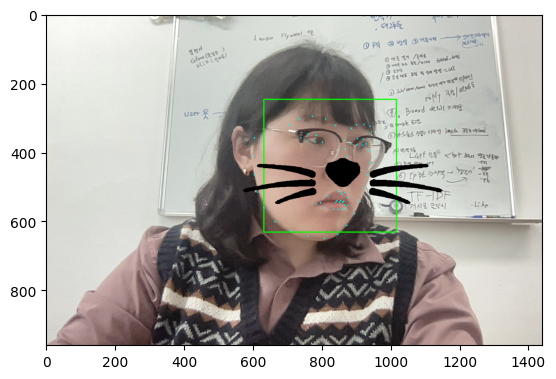

1

In [37]:
def snow_image(img_dir, sticker_dir, guide_line):


  my_image_path = img_dir # 본인 이미지가 있는 경로를 가지고 온다.
  img_bgr = cv2.imread(my_image_path)    # OpenCV로 이미지를 불러옵니다
  # plt.imshow 이전에 RGB 이미지로 바꾸는 것을 잊지마세요.
  img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

  # detector를 선언합니다
  detector_hog = dlib.get_frontal_face_detector() # 기본 얼굴 감지기를 반환

  img_show = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
  dlib_rects = detector_hog(img_rgb, 1)   # (image, num of image pyramid)

  # 찾은 얼굴 영역 박스 리스트
  # 여러 얼굴이 있을 수 있습니다
  print(dlib_rects)

  for dlib_rect in dlib_rects: # 찾은 얼굴 영역의 좌표
      l = dlib_rect.left() # 왼쪽
      t = dlib_rect.top() # 위쪽
      r = dlib_rect.right() # 오른쪽
      b = dlib_rect.bottom() # 아래쪽

      cv2.rectangle(img_show, (l,t), (r,b), (0,255,0), 2, lineType=cv2.LINE_AA) # 시작점의 좌표와 종료점 좌표로 직각 사각형을 그림

  model_path =  '/content/models/shape_predictor_68_face_landmarks.dat'
      # 저장한 landmark 모델의 주소를 model_path 변수에 저장
  landmark_predictor = dlib.shape_predictor(model_path)
      # dlib 라이브러리의 shape_predictor 함수를 이용하여 모델을 불러옴
      # landmark_predictor는 RGB이미지와 dlib.rectangle를 입력 받고 dlib.full_object_detection를 반환
      # dlib.rectangle: 내부를 예측하는 박스
      # dlib.full_object_detection: 각 구성 요소의 위치와, 이미지 상의 객체의 위치를 나타냄
  list_landmarks = []
      # 랜드마크의 위치를 저장할 list 생성

  # 얼굴 영역 박스 마다 face landmark를 찾아냅니다
  # face landmark 좌표를 저장해둡니다
  for dlib_rect in dlib_rects:
      points = landmark_predictor(img_rgb, dlib_rect)
          # 모든 landmark의 위치정보를 points 변수에 저장
      list_points = list(map(lambda p: (p.x, p.y), points.parts()))
          # 각각의 landmark 위치정보를 (x,y) 형태로 변환하여 list_points 리스트로 저장
      list_landmarks.append(list_points)
          # list_landmarks에 랜드마크 리스트를 저장

  print(len(list_landmarks[0]))
      # 얼굴이 n개인 경우 list_landmarks는 n개의 원소를 갖고
      # 각 원소는 68개의 랜드마크 위치가 나열된 list
      # list_landmarks의 원소가 1개이므로 list_landmarks[1]을 호출하면 IndexError가 발생

  # list_landmarks의 원소가 1개이므로 아래 반복문은 한번만 실행됨
  for landmark in list_landmarks:
      for point in landmark:
          cv2.circle(img_show, point, 2, (0, 255, 255), -1)
              # cv2.circle: OpenCV의 원을 그리는 함수
              # img_show 이미지 위 각각의 point에
              # 크기가 2이고 (0, 255, 255)색으로 내부가 채워진(-1) 원을 그림
              # (마지막 인수가 자연수라면 그만큼의 두께의 선으로 원이 그려짐)

  # zip() : 두 그룹의 데이터를 서로 엮어주는 파이썬의 내장 함수
  # dlib_rects와 list_landmarks 데이터를 엮어 주었음
  # dlib_rects : 얼굴 영역을 저장하고 있는 값
  # → rectangles[[(345, 98) (531, 284)]]
  # list_landmarks : 68개의 랜드마크 값 저장(이목구비 위치(x,y))
  # → [[(368, 153), (368, 174), (371, 195), (376, 215), (382, 235), (391, 252), (404, 266), (420, 277), (441, 279), (461, 276), (480, 266), (495, 252), (508, 235), (516, 216), (520, 195), (523, 173), (524, 151), (377, 131), (386, 119), (399, 116), (413, 118), (425, 124), (454, 121), (466, 114), (481, 112), (494, 114), (503, 127), (439, 143), (438, 156), (438, 169), (437, 182), (423, 197), (431, 199), (438, 200), (446, 199), (454, 197), (391, 147), (399, 142), (409, 143), (416, 149), (408, 150), (399, 150), (464, 147), (472, 141), (482, 141), (489, 145), (482, 149), (473, 149), (411, 227), (421, 222), (432, 218), (439, 220), (446, 218), (458, 222), (471, 227), (458, 234), (446, 238), (438, 238), (431, 238), (420, 235), (415, 227), (432, 227), (439, 228), (447, 227), (466, 227), (446, 228), (438, 229), (431, 228)]]

  for dlib_rect, landmark in zip(dlib_rects, list_landmarks): # 얼굴 영역을 저장하고 있는 값과 68개의 랜드마크를 저장하고 있는 값으로 반복문 실행
      print (landmark[33]) # 코의 index는 30 입니다
      x = landmark[33][0] # 이미지에서 코 부위의 x값
      y = landmark[33][1] - dlib_rect.height()//2 # 이미지에서 코 부위의 y값 - 얼굴 영역의 세로를 차지하는 픽셀의 수//2 → (437, 182-(186+1//2))
      w = h = dlib_rect.width() # 얼굴 영역의 가로를 차지하는 픽셀의 수 (531-345+1) → max(x) - min(x) +1(픽셀의 수 이기 때문에 1을 더해줌 → 픽셀 수는 점 하나로도 1이 됨)
      print (f'(x,y) : ({x},{y})')
      print (f'(w,h) : ({w},{h})')



  sticker_path = sticker_dir # 고양이 수염 이미지의 경로
  img_sticker = cv2.imread(sticker_path) # 스티커 이미지를 불러옵니다 // cv2.imread(이미지 경로) → image객체 행렬을 반환

  for dlib_rect, landmark in zip(dlib_rects, list_landmarks):
      # Get the nose tip coordinates (index 33 for dlib's 68-point model)
      # These are the actual (x, y) coordinates on the face, not adjusted yet
      nose_x = landmark[33][0]
      nose_y = landmark[33][1]

  factor = 1.5
  if w < 200 :
    factor = 0.5
  elif w  <350 :
    factor = 1.0

  # 이 값을 조절하여 스티커의 크기를 얼굴 크기에 비례하게 바꿀 수 있습니다.
  sticker_scale_factor = factor # 스티커 크기 조절을 위한 배율 (1.0은 얼굴 너비와 동일)

  # 스티커의 새로운 너비와 높이를 계산
  new_sticker_width = int(w * sticker_scale_factor)
  new_sticker_height = int(h * sticker_scale_factor)

  # 스티커 이미지 조정
  img_sticker = cv2.resize(img_sticker, (new_sticker_width, new_sticker_height))

  # 스티거의 사이즈
  sticker_width = img_sticker.shape[1]
  sticker_height = img_sticker.shape[0]
  # 재계산한 x,y 값
  refined_x = nose_x - sticker_width // 2
  refined_y = nose_y - sticker_height // 2  # 조금 미세한 조정을 위해 4분할한 이미지 크기만큼 빼줌

  # 이미지 임시 저장
  temp_img_sticker = img_sticker.copy()

  #음수 값 소멸시키기
  if refined_x < 0:
      temp_img_sticker = temp_img_sticker[:, -refined_x:]
      refined_x = 0
  if refined_y < 0:
      temp_img_sticker = temp_img_sticker[-refined_y:, :]
      refined_y = 0

  # 임시 스티커 이미지 사이즈로부터 현재 이미지 높이 너비 가져오기
  current_sticker_height = temp_img_sticker.shape[0]
  current_sticker_width = temp_img_sticker.shape[1]

  # 원본 이미지의 shape
  img_height, img_width, _ = img_show.shape

  # 가로와 세로 길이에 따라 이미지 사이즈 자르기
  if refined_x + current_sticker_width > img_width:
      current_sticker_width = img_width - refined_x
      temp_img_sticker = temp_img_sticker[:, :current_sticker_width]

  if refined_y + current_sticker_height > img_height:
      current_sticker_height = img_height - refined_y
      temp_img_sticker = temp_img_sticker[:current_sticker_height, :]

  # 이미지 원본에서 스티커 위치 정하기
  sticker_area = img_show[refined_y : refined_y + current_sticker_height,
                          refined_x : refined_x + current_sticker_width]

  # 이미지 show
      #np.where : 조건에 만족하는 인덱스를 찾아 적용하기
  img_show[refined_y : refined_y + current_sticker_height,
            refined_x : refined_x + current_sticker_width] = \
      np.where(temp_img_sticker == 0, temp_img_sticker, sticker_area).astype(np.uint8)

  # 위에서 설명했으므로 생략
  # 고양이 수염 이미지
  sticker_area = img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]]
  # img_bgr은 7-2에서 rgb로만 적용해놓은 원본 이미지이다.
  img_bgr[refined_y:refined_y +img_sticker.shape[0], refined_x:refined_x+img_sticker.shape[1]] = \
      np.where(img_sticker!=0,sticker_area,img_sticker).astype(np.uint8)

  if guide_line:
    plt.imshow(img_show)
  else:
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

  plt.show()

  return 1


snow_image('/content/haji_03.jpg','/content/cat_whiskers.png',True)

## 문제점
1.   얼굴 각도에 따라 스티커가 어떻게 변해야할까요?
2.   멀리서 촬영하면 왜 안될까요? 옆으로 누워서 촬영하면 왜 안될까요?
3.   실행 속도가 중요할까요?
4.   스티커앱을 만들 때 정확도가 얼마나 중요할까요?



